In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

# 1. Load Data
df_matches = pd.read_csv("./data/gold_match.csv")
df_promo = pd.read_csv("./data/gold_match_context.csv")
df_tickets = pd.read_csv("./data/gold_match_ticket.csv")

# 2. Merge and Filter
df = pd.merge(df_matches, df_promo, on='match_id', how='left', suffixes=('', '_drop'))
df = pd.merge(df, df_tickets, on='match_id', how='left', suffixes=('', '_drop'))
df = df.filter(regex='^(?!.*_drop)')
df = df[df['is_home_match'] == True].copy()

# 3. Feature Engineering
df['hour'] = pd.to_datetime(df['kickoff_time_local']).dt.hour
df['match_date'] = pd.to_datetime(df['match_date'])
df = df.sort_values('match_date')
df['days_since_last_home'] = df['match_date'].diff().dt.days.fillna(14)
df['season'] = df['match_date'].apply(lambda x: x.year if x.month >= 7 else x.year - 1)

# 4. Split Data (Keep shuffle=True for small N=71 to get a mix of seasons)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# 5. Target Encoding (Strongest signal for small data)
team_averages = df_train.groupby("away_team")["tickets_scanned"].mean()
df_train = df_train.copy()
df_test = df_test.copy()
df_train['opponent_strength'] = df_train['away_team'].map(team_averages)
df_test['opponent_strength'] = df_test['away_team'].map(team_averages)
df_test['opponent_strength'] = df_test['opponent_strength'].fillna(df_train['tickets_scanned'].mean())

# 6. Simplified Variable Selection
# For N=71, we shouldn't use too many categories. 
# We'll use 'is_weekend' and 'is_public_holiday' as they are high-level.
num_cols = [
    'tickets_sold_total', 
    'opponent_strength', 
    'weather_temp_max_c', 
    'weather_precipitation_mm', 
    'hour',
    'promo_tickets_total'
]

# 7. Final X and y assignment
X_train = df_train[num_cols]
y_train = df_train['tickets_scanned']
X_test = df_test[num_cols]
y_test = df_test['tickets_scanned']

# 8. Simplified Pipeline (Ridge Regression is better for small data)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LassoCV(cv=5, random_state=42))
])

# 9. Train and Evaluate
model_pipeline.fit(X_train, y_train)
preds = model_pipeline.predict(X_test)

# 10. Cross-Validation (More reliable for N=71)
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='r2')

print(f"--- Small Dataset Results (N=71) ---")
print(f"MAE:  {mean_absolute_error(y_test, preds):.2f}")
print(f"R2 Score (Test Set): {r2_score(y_test, preds):.2f}")
print(f"Average CV R2 Score: {cv_scores.mean():.2f}")

C:\Users\nterh\AppData\Local\Temp\ipykernel_27432\1374604301.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['kickoff_time_local']).dt.hour


--- Small Dataset Results (N=71) ---
MAE:  1480.65
R2 Score (Test Set): 0.00
Average CV R2 Score: 0.41


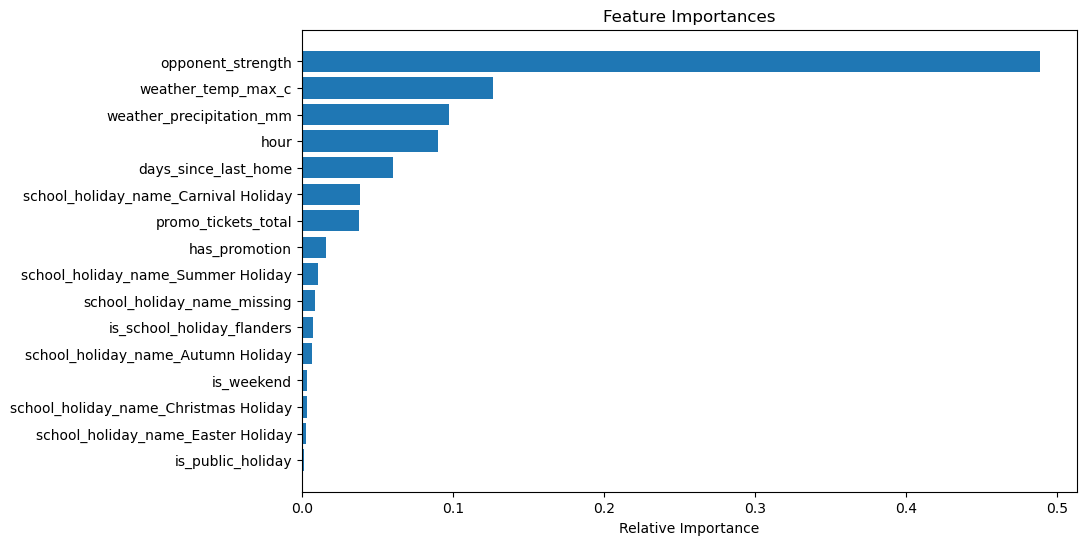

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Reach into the pipeline to get the Random Forest model
rf_model = model_pipeline.named_steps['regressor'].estimators_[0]

# 2. Get the feature names from the preprocessor
# (This correctly labels the 'Tier_Bottom', 'Tier_Middle', etc. names)
cat_names = model_pipeline.named_steps['preprocessor']\
            .named_transformers_['cat']\
            .named_steps['ohe']\
            .get_feature_names_out(cat_cols)

# Combine all names in the order they entered the model
feature_names = list(cat_names) + num_cols + bool_cols

# 3. Plot it
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [23]:
df['tickets_scanned'].describe()

count       71.000000
mean      6861.577465
std       1996.145941
min       3537.000000
25%       5425.000000
50%       6399.000000
75%       8015.000000
max      11069.000000
Name: tickets_scanned, dtype: float64

In [5]:
# Create a summary of the 14 test games
test_results = df_test.copy()
test_results['Predicted'] = preds
test_results['Error'] = test_results['tickets_scanned'] - test_results['Predicted']
test_results['Abs_Error'] = test_results['Error'].abs()

# Sort by the biggest misses
biggest_misses = test_results[['match_date', 'away_team', 'tickets_scanned', 'Predicted', 'Error']].sort_values(by='Error', ascending=False)

print("--- Top 5 Under-estimations (Model guessed too low) ---")
print(biggest_misses.head(5))

print("\n--- Top 5 Over-estimations (Model guessed too high) ---")
print(biggest_misses.tail(5))

--- Top 5 Under-estimations (Model guessed too low) ---
   match_date     away_team  tickets_scanned    Predicted        Error
63 2024-03-17      Mechelen          11069.0  7400.815324  3668.184676
26 2023-02-26       Antwerp           9331.0  6492.104301  2838.895699
37 2023-08-18       Antwerp           8577.0  6839.770336  1737.229664
44 2023-10-22  Sint-Truiden           7784.0  6472.465083  1311.534917
11 2022-10-15          Genk           7238.0  6390.668603   847.331397

--- Top 5 Over-estimations (Model guessed too high) ---
    match_date   away_team  tickets_scanned     Predicted        Error
110 2025-05-03    Mechelen           5615.0   6323.834825  -708.834825
107 2025-04-19      Dender           4252.0   5008.908761  -756.908761
66  2024-04-14        Gent           4936.0   6879.563141 -1943.563141
122 2025-09-26  Anderlecht           6977.0  10133.972914 -3156.972914
20  2023-01-17       Eupen           3537.0   6852.772729 -3315.772729
